In [274]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import torch;
print(torch.__version__)
# add parent folder (production) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAM

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

2.7.1+cpu
c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


(1024,)
(512, 9)
[[ 3.88117797e-03 -2.25295938e-06 -6.93698049e-05 ... -6.93698049e-05
  -2.25295938e-06 -3.93132203e-03]
 [-9.27342622e-03  2.06156691e-06  5.25546101e-05 ... -9.45377634e-05
  -2.80340574e-06 -9.60187996e-03]
 [-3.88392664e-03 -1.65585932e-06 -3.95050152e-05 ... -1.28897536e-04
  -3.12388830e-06  3.93312201e-03]
 ...
 [-9.94936625e-03  3.89211799e-06  1.80638790e-04 ... -3.08395297e-05
  -1.54420069e-06 -8.96466928e-03]
 [-3.87937799e-03 -3.12388830e-06 -1.28897536e-04 ... -3.95050153e-05
  -1.65585931e-06  3.92857336e-03]
 [ 9.60187996e-03  2.80340574e-06  9.45377634e-05 ... -5.25546101e-05
  -2.06156691e-06  9.27342622e-03]]
torch.Size([512, 9])


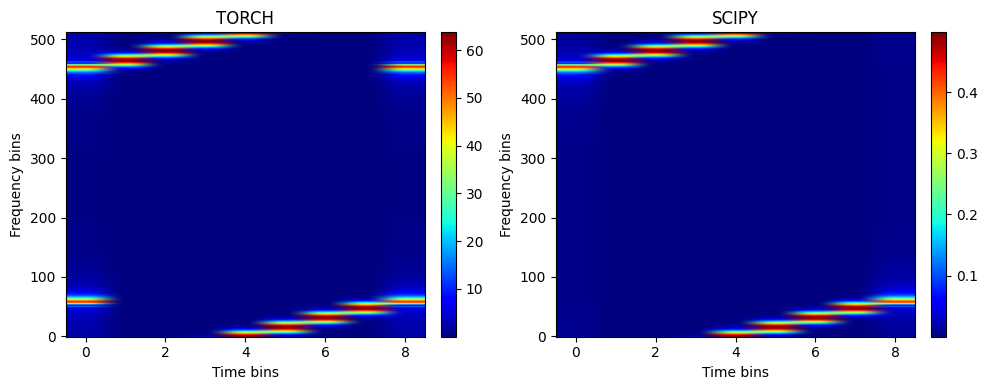

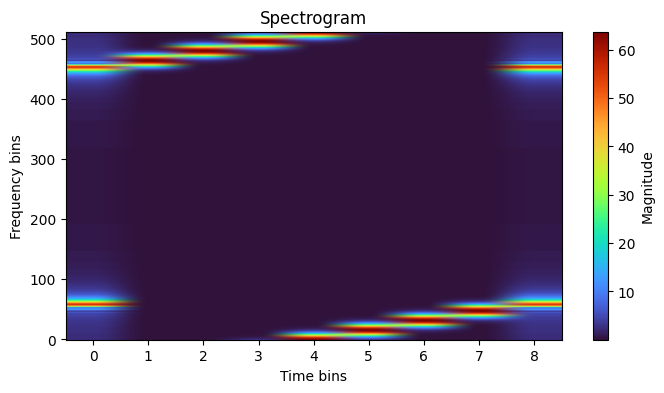

In [ ]:
# ---- Example usage with your LoRa generator ----
sf = 9
bw = 125000
fs = 500000
lora_init = LoRa(sf, bw)
x1 = lora_init.gen_symbol_fs(0, sf, bw, down=False, Fs=fs) # you had Fs=int(bw*8)=1e6
print(x1.shape)
a,b,asa,ds,ds,ds =create_spectrogram_npy_dual(x1,fs,0,0,0,None,None)
print(a)
x= create_spectrogram_from_torch(x1)
print(x.shape)
magnitude = np.sqrt(a**2 + b**2)
mag_db = 20 * np.log10(magnitude + 1e-9)

show_multiple_spectrograms([torch.abs(x).numpy(),magnitude],["TORCH","SCIPY"],2)

import matplotlib.pyplot as plt
import numpy as np
S = torch.abs(x).numpy()
plt.figure(figsize=(8,4))
plt.imshow(
    S, 
    aspect='auto', 
    origin='lower',        # LOW FREQUENCY at bottom (correct orientation)
    cmap='turbo'           # or 'viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.title("Spectrogram")
plt.show()


torch.Size([257, 33])


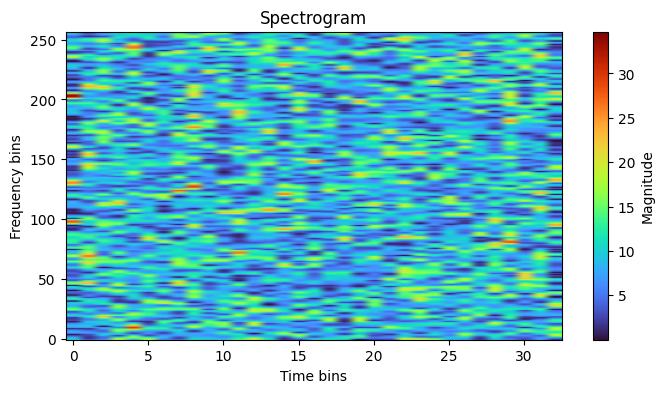

In [276]:
# Generate a simple audio signal
signal = torch.randn(4096)
 
# Compute the STFT
stft = torch.stft(signal, n_fft=512, hop_length=128, win_length=256, window=torch.hamming_window(256),return_complex=True)
 
print(stft.shape)

S = torch.abs(stft).numpy()
plt.figure(figsize=(8,4))
plt.imshow(
    S, 
    aspect='auto', 
    origin='lower',        # LOW FREQUENCY at bottom (correct orientation)
    cmap='turbo'           # or 'viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.title("Spectrogram")
plt.show()